# Fictalent · Auditoria de qualidade · pessoas, quem foi admitido e onde está alocado
<a id="topo"></a>

[Home](../../README.md) | [Auditoria](README.md) | [Entendimento dos dados](../../docs/02_entendimento_dados.md)

**Autor:** Tiago Lima
**Projeto:** rh-fictalent-bigdata · fase 6, lake (v0.6.0)
**Cliente:** Fictalent (empresa fictícia; dado sintético)
**Data:** 24/09/2026

**Objetivo:** auditar o ciclo de vida do colaborador: admissão, contrato de trabalho (temporário, efetivo, terceirizado), a alocação no posto (a tabela mais importante do banco: é dela que sai o headcount de qualquer dia e o custo por contrato), afastamentos e desligamento. O cliente declarou dois defeitos aqui, e os dois entram como hipóteses: admissões lançadas depois do fato, com data anterior à do próprio cadastro, e contratos temporários que passaram do prazo legal sem aditivo.

**Base analisada:** a bronze do lake, lida pelo DuckDB com os nomes da réplica, só as linhas vivas (as marcadas como excluídas ficam de fora). Tabelas do domínio `pessoas`: `colaborador`, `colaborador_documento`, `dependente`, `contrato_trabalho`, `contrato_trabalho_prorrogacao`, `alocacao`, `afastamento`, `desligamento`.

**Regra desta auditoria: às cegas.** O notebook procura os defeitos no dado com o esquema (a DDL) e o entendimento do negócio ([`docs/02`](../../docs/02_entendimento_dados.md)) como únicas referências. Ele não consulta o gerador da base sintética nem a régua de validação, e um teste garante isso. As declarações do cliente sobre a qualidade dos próprios dados entram como **hipóteses**, testadas aqui, não como resposta.

**Perguntas-guia:**

1. Há admissões retroativas: a data de admissão anterior ao dia em que o registro foi criado? (declaração)
2. Há contratos temporários além de 180 dias sem prorrogação, ou além de 270 dias no total? (declaração)
3. A alocação respeita o contrato de trabalho e o posto (começa depois da admissão, termina antes da rescisão, dentro da vigência do posto), sem duas alocações ao mesmo tempo?
4. Status, datas e desligamento contam a mesma história para cada contrato?

**Sumário:**

1. [Configuração](#secao-1)
2. [A fotografia da carga](#secao-2)
3. [Perfil das colunas](#secao-3)
4. [Completude](#secao-4)
5. [Unicidade](#secao-5)
6. [Domínios declarados](#secao-6)
7. [Texto e documentos](#secao-7)
8. [Cronologia do vínculo](#secao-8)
9. [Integridade referencial](#secao-9)
10. [Regras do domínio e declarações](#secao-10)
11. [Fechamento](#secao-11)

<a id="secao-1"></a>

# 1. Configuração

O acesso ao dado passa pelo pacote do projeto: endereço e credencial do lake vêm do `.env`, e o notebook não conhece nenhum dos dois. Assim ele roda na máquina de qualquer pessoa com a plataforma de pé, sem editar uma linha.

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from rh_fictalent.auditoria import achados, checagens, esquema
from rh_fictalent.ingestao import marca_dagua
from rh_fictalent.lake import consulta
from rh_fictalent.orquestracao.recursos import lake_do_ambiente, warehouse_do_ambiente

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "auditoria" else Path.cwd()
load_dotenv(RAIZ / ".env")

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 4.5)

print(f"Python {sys.version.split()[0]}")
for modulo in (pd, duckdb, matplotlib):
    print(f"{modulo.__name__:<12}{modulo.__version__}")

Python 3.12.3
pandas      3.0.5
duckdb      1.5.5
matplotlib  3.11.2


In [2]:
lake = lake_do_ambiente()
con = consulta.abrir(lake)
tabelas = esquema.do_modulo("pessoas")
nomes = [t.qualificado for t in tabelas]
registro = achados.Registro("pessoas")
print(f"{len(tabelas)} tabelas do domínio: {', '.join(t.nome for t in tabelas)}")

8 tabelas do domínio: colaborador, colaborador_documento, dependente, contrato_trabalho, contrato_trabalho_prorrogacao, alocacao, afastamento, desligamento


## Nota Técnica

**Observado:** mesma configuração; as 8 tabelas do domínio lidas da DDL.

**Por que importa:** o notebook não conhece credencial nem caminho de máquina.

**Ação:** nenhuma.

<a id="secao-2"></a>

# 2. A fotografia da carga

Toda conclusão descreve um instante. A marca d'água da ingestão diz até quando a bronze acompanha a réplica, e a contagem de linhas vivas diz o tamanho do que foi auditado. Os dois são lidos, não digitados, para não envelhecerem.

In [3]:
marcas = marca_dagua.ler(warehouse_do_ambiente())
do_dominio = {n: marcas[n] for n in nomes if n in marcas}
REFERENCIA = max(m.marca for m in do_dominio.values())
HOJE = REFERENCIA.date()
print(f"Marca d'água mais recente do domínio: {REFERENCIA:%d/%m/%Y %H:%M}")
print(f"Data de referência das regras com prazo (\"hoje\" do dado): {HOJE:%d/%m/%Y}")

volume = pd.DataFrame(
    [{"tabela": n, "linhas_vivas": checagens.linhas(con, n), "marca": do_dominio[n].marca if n in do_dominio else None} for n in nomes]
)
TOTAL = int(volume["linhas_vivas"].sum())
print(f"Linhas vivas no domínio: {TOTAL:,}".replace(",", "."))
volume

Marca d'água mais recente do domínio: 24/09/2026 15:02
Data de referência das regras com prazo ("hoje" do dado): 24/09/2026
Linhas vivas no domínio: 108.852


,tabela,linhas_vivas,marca
0,pessoas.colaborador,15558,2026-09-24 15:02:06.227515
1,pessoas.colaborador_documento,31116,2026-09-24 15:02:06.227515
2,pessoas.dependente,10795,2026-09-24 15:02:06.227515
3,pessoas.contrato_trabalho,16992,2026-09-24 15:02:06.227515
4,pessoas.contrato_trabalho_prorrogacao,207,2026-09-24 15:02:06.227515
5,pessoas.alocacao,16992,2026-09-24 15:02:06.227515
6,pessoas.afastamento,1058,2026-09-24 15:02:06.227515
7,pessoas.desligamento,16134,2026-09-24 15:02:06.227515


## Nota Técnica

**Observado:** 108.852 linhas vivas: 15.558 colaboradores com 31.116 documentos e 10.795 dependentes, 16.992 contratos de trabalho (15.064 temporários) com 207 prorrogações, 16.992 alocações, 1.058 afastamentos e 16.134 desligamentos.

**Por que importa:** a alocação é a tabela mais importante do banco (é dela que sai o headcount de qualquer dia e o custo por contrato) e o contrato de trabalho carrega a obrigação legal do temporário. Defeito aqui é risco jurídico e margem errada.

**Ação:** nenhuma.

<a id="secao-3"></a>

# 3. Perfil das colunas

Antes de procurar defeito é preciso saber o que há. Uma linha por coluna: tipo, nulos, distintos, mínimo e máximo. É o mapa que orienta as seções seguintes: coluna toda nula, coluna com um valor só, data fora do arco.

In [4]:
perfis = pd.concat([checagens.perfil(con, n) for n in nomes], ignore_index=True)
constantes = perfis[(perfis["distintos"] <= 1) & (perfis["nulos"] == 0) & (perfis["tipo"] != "BOOLEAN")]
vazias = perfis[perfis["pct_nulo"] >= 100]
print(f"{len(perfis)} colunas em {len(nomes)} tabelas")
print(f"Colunas com um valor só: {len(constantes)}" + (f" ({', '.join(constantes['tabela'] + '.' + constantes['coluna'])})" if len(constantes) else ""))
print(f"Colunas totalmente vazias: {len(vazias)}" + (f" ({', '.join(vazias['tabela'] + '.' + vazias['coluna'])})" if len(vazias) else ""))
perfis

78 colunas em 8 tabelas
Colunas com um valor só: 1 (pessoas.contrato_trabalho_prorrogacao.dias_adicionais)
Colunas totalmente vazias: 0


,tabela,coluna,tipo,nulos,pct_nulo,distintos,minimo,maximo
0,pessoas.colaborador,id,BIGINT,0,0.00,13507,1,15558
1,pessoas.colaborador,candidato_id,BIGINT,0,0.00,17610,1,59876
2,pessoas.colaborador,matricula,VARCHAR,0,0.00,13818,F000001,F015558
3,pessoas.colaborador,nome,VARCHAR,0,0.00,13059,Adriana Almeida Alves,Wesley Vieira Soares
4,pessoas.colaborador,cpf,VARCHAR,0,0.00,13560,00004343883,99996063267
5,pessoas.colaborador,dt_nascimento,DATE,0,0.00,7384,1962-03-10,2008-08-12
6,pessoas.colaborador,municipio_id,BIGINT,0,0.00,42,1,108
7,pessoas.colaborador,endereco_id,BIGINT,0,0.00,13155,164,15721
8,pessoas.colaborador,pis,VARCHAR,0,0.00,15461,00010231072,99987495495
9,pessoas.colaborador,dt_admissao_primeira,DATE,0,0.00,2544,2018-01-10,2026-09-10


In [5]:
# a bronze promete ser espelho da réplica também no tipo: um inteiro copiado como booleano vira True em toda linha, e nenhuma contagem acusa
tipos = pd.concat([checagens.tipos(con, t) for t in tabelas], ignore_index=True)
incompativeis = tipos[~tipos["compativel"]]
print(f"{len(tipos)} colunas com o tipo conferido contra a DDL; incompatíveis: {len(incompativeis)}")
incompativeis

78 colunas com o tipo conferido contra a DDL; incompatíveis: 0


,tabela,coluna,ddl,bronze,compativel


## Nota Técnica

**Observado:** 78 colunas, tipos compatíveis com a DDL, nenhuma vazia; uma constante, `contrato_trabalho_prorrogacao.dias_adicionais`, sempre 90: toda prorrogação é pelo máximo legal.

**Por que importa:** prorrogação sempre de 90 dias é regra de negócio consistente (o prazo do temporário é 180 mais 90), não defeito.

**Ação:** nenhuma.

<a id="secao-4"></a>

# 4. Completude

Nulo testado pela coerência: contrato encerrado sem data de rescisão, temporário sem prazo legal, desligamento sem homologação, colaborador sem vínculo ao candidato que ele foi.

In [6]:
obrigatorias = {(t.qualificado, c.nome) for t in tabelas for c in t.colunas if not c.nulo}
com_nulos = perfis[perfis["nulos"] > 0].sort_values("pct_nulo", ascending=False)
com_nulos = com_nulos.assign(obrigatoria=[(t, c) in obrigatorias for t, c in zip(com_nulos["tabela"], com_nulos["coluna"])])
print(f"Colunas com algum nulo: {len(com_nulos)}; delas, declaradas NOT NULL: {int(com_nulos['obrigatoria'].sum())}")
com_nulos[["tabela", "coluna", "tipo", "nulos", "pct_nulo", "obrigatoria"]]

Colunas com algum nulo: 9; delas, declaradas NOT NULL: 0


,tabela,coluna,tipo,nulos,pct_nulo,obrigatoria
56,pessoas.alocacao,substituindo_alocacao_id,BIGINT,4520,26.60,False
34,pessoas.contrato_trabalho,dt_prevista_termino,DATE,3209,18.89,False
65,pessoas.afastamento,cid_grupo,VARCHAR,125,11.81,False
38,pessoas.contrato_trabalho,prazo_legal_dias,BIGINT,1928,11.35,False
35,pessoas.contrato_trabalho,dt_rescisao,DATE,858,5.05,False
55,pessoas.alocacao,motivo_fim_id,BIGINT,858,5.05,False
54,pessoas.alocacao,dt_fim,DATE,858,5.05,False
63,pessoas.afastamento,dt_fim,DATE,7,0.66,False
75,pessoas.desligamento,dt_homologacao,DATE,30,0.19,False


In [7]:
coerencia = consulta.sql(con, '''
    SELECT 'contrato ENCERRADO sem dt_rescisao' AS caso, count(*) AS linhas FROM pessoas.contrato_trabalho WHERE excluido_em IS NULL AND status = 'ENCERRADO' AND dt_rescisao IS NULL
    UNION ALL SELECT 'contrato ATIVO com dt_rescisao', count(*) FROM pessoas.contrato_trabalho WHERE excluido_em IS NULL AND status = 'ATIVO' AND dt_rescisao IS NOT NULL
    UNION ALL SELECT 'TEMPORARIO sem prazo_legal_dias', count(*) FROM pessoas.contrato_trabalho WHERE excluido_em IS NULL AND tipo = 'TEMPORARIO' AND prazo_legal_dias IS NULL
    UNION ALL SELECT 'TEMPORARIO sem dt_prevista_termino', count(*) FROM pessoas.contrato_trabalho WHERE excluido_em IS NULL AND tipo = 'TEMPORARIO' AND dt_prevista_termino IS NULL
    UNION ALL SELECT 'nao TEMPORARIO com prazo_legal_dias', count(*) FROM pessoas.contrato_trabalho WHERE excluido_em IS NULL AND tipo <> 'TEMPORARIO' AND prazo_legal_dias IS NOT NULL
    UNION ALL SELECT 'contrato ENCERRADO sem desligamento', count(*) FROM pessoas.contrato_trabalho k WHERE k.excluido_em IS NULL AND k.status = 'ENCERRADO' AND NOT EXISTS (SELECT 1 FROM pessoas.desligamento d WHERE d.excluido_em IS NULL AND d.contrato_trabalho_id = k.id)
    UNION ALL SELECT 'desligamento de contrato ATIVO', count(*) FROM pessoas.desligamento d JOIN pessoas.contrato_trabalho k ON k.id = d.contrato_trabalho_id WHERE d.excluido_em IS NULL AND k.excluido_em IS NULL AND k.status = 'ATIVO'
    UNION ALL SELECT 'colaborador ativo sem contrato ATIVO', count(*) FROM pessoas.colaborador p WHERE p.excluido_em IS NULL AND p.ativo AND NOT EXISTS (SELECT 1 FROM pessoas.contrato_trabalho k WHERE k.excluido_em IS NULL AND k.colaborador_id = p.id AND k.status = 'ATIVO')
    UNION ALL SELECT 'colaborador inativo com contrato ATIVO', count(*) FROM pessoas.colaborador p WHERE p.excluido_em IS NULL AND NOT p.ativo AND EXISTS (SELECT 1 FROM pessoas.contrato_trabalho k WHERE k.excluido_em IS NULL AND k.colaborador_id = p.id AND k.status = 'ATIVO')
    UNION ALL SELECT 'colaborador sem candidato de origem', count(*) FROM pessoas.colaborador WHERE excluido_em IS NULL AND candidato_id IS NULL
    UNION ALL SELECT 'colaborador sem endereco', count(*) FROM pessoas.colaborador WHERE excluido_em IS NULL AND endereco_id IS NULL
    UNION ALL SELECT 'colaborador sem PIS', count(*) FROM pessoas.colaborador WHERE excluido_em IS NULL AND pis IS NULL
    UNION ALL SELECT 'colaborador sem nenhum documento', count(*) FROM pessoas.colaborador p WHERE p.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM pessoas.colaborador_documento d WHERE d.excluido_em IS NULL AND d.colaborador_id = p.id)
    UNION ALL SELECT 'colaborador sem CTPS', count(*) FROM pessoas.colaborador p WHERE p.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM pessoas.colaborador_documento d WHERE d.excluido_em IS NULL AND d.colaborador_id = p.id AND d.tipo = 'CTPS')
    UNION ALL SELECT 'alocacao encerrada sem motivo de fim', count(*) FROM pessoas.alocacao WHERE excluido_em IS NULL AND dt_fim IS NOT NULL AND motivo_fim_id IS NULL
    UNION ALL SELECT 'alocacao vigente com motivo de fim', count(*) FROM pessoas.alocacao WHERE excluido_em IS NULL AND dt_fim IS NULL AND motivo_fim_id IS NOT NULL
    UNION ALL SELECT 'afastamento ATESTADO/ACIDENTE sem CID', count(*) FROM pessoas.afastamento WHERE excluido_em IS NULL AND tipo IN ('ATESTADO', 'ACIDENTE') AND cid_grupo IS NULL
    UNION ALL SELECT 'afastamento LICENCA/SUSPENSAO com CID', count(*) FROM pessoas.afastamento WHERE excluido_em IS NULL AND tipo IN ('LICENCA', 'SUSPENSAO') AND cid_grupo IS NOT NULL
    UNION ALL SELECT 'desligamento sem homologacao', count(*) FROM pessoas.desligamento WHERE excluido_em IS NULL AND dt_homologacao IS NULL
''')
print(f"Testes de coerência: {len(coerencia)}; com linhas: {int((coerencia['linhas'] > 0).sum())}")
print(coerencia.to_string(index=False))

Testes de coerência: 19; com linhas: 2
                                  caso  linhas
    contrato ENCERRADO sem dt_rescisao       0
        contrato ATIVO com dt_rescisao       0
       TEMPORARIO sem prazo_legal_dias       0
    TEMPORARIO sem dt_prevista_termino    1281
   nao TEMPORARIO com prazo_legal_dias       0
   contrato ENCERRADO sem desligamento       0
        desligamento de contrato ATIVO       0
  colaborador ativo sem contrato ATIVO       0
colaborador inativo com contrato ATIVO       0
   colaborador sem candidato de origem       0
              colaborador sem endereco       0
                   colaborador sem PIS       0
      colaborador sem nenhum documento       0
                  colaborador sem CTPS       0
  alocacao encerrada sem motivo de fim       0
    alocacao vigente com motivo de fim       0
 afastamento ATESTADO/ACIDENTE sem CID       0
 afastamento LICENCA/SUSPENSAO com CID       0
          desligamento sem homologacao      30


In [8]:
sem_previsao = consulta.sql(con, "SELECT year(dt_admissao) AS ano, count(*) AS temporarios, count(*) FILTER (WHERE dt_prevista_termino IS NULL) AS sem_previsao, prazo_legal_dias FROM pessoas.contrato_trabalho WHERE excluido_em IS NULL AND tipo = 'TEMPORARIO' GROUP BY 1, 4 ORDER BY 1, 4")
print(sem_previsao.to_string(index=False))
homolog = consulta.sql(con, "SELECT count(*) AS sem_homologacao, min(dt_desligamento) AS primeiro, max(dt_desligamento) AS ultimo, count(*) FILTER (WHERE date_diff('day', dt_desligamento, ?) <= 30) AS nos_ultimos_30_dias FROM pessoas.desligamento WHERE excluido_em IS NULL AND dt_homologacao IS NULL", HOJE)
print(homolog.to_string(index=False))
n_temporarios = checagens.contar(con, "SELECT count(*) FROM pessoas.contrato_trabalho WHERE excluido_em IS NULL AND tipo = 'TEMPORARIO'")
n_desligamentos = checagens.linhas(con, "pessoas.desligamento")
registro.anotar(
    secao="4", tabela="pessoas.contrato_trabalho", coluna="dt_prevista_termino",
    achado="contrato temporário sem data prevista de término", linhas=int(sem_previsao["sem_previsao"].sum()), total=n_temporarios, severidade="media",
    impacto="nenhum alerta de prazo alcança o contrato: é por aqui que o temporário passa dos 180 dias sem ninguém ver",
    acao="a silver deriva a previsão (admissão mais o prazo legal) marcando que foi derivada; o cliente passa a exigir o campo na admissão",
)
registro.anotar(
    secao="4", tabela="pessoas.desligamento", coluna="dt_homologacao",
    achado="desligamento sem homologação, todos dos últimos 30 dias: pendência de prazo, não defeito", linhas=0, total=n_desligamentos, severidade="nenhuma",
    impacto="a homologação tem prazo legal; dentro dele o nulo é legítimo", acao="nenhuma; o painel pode listar os pendentes",
)
print(f"anotados: {len(registro)}")

 ano  temporarios  sem_previsao  prazo_legal_dias
2018          258            17               180
2018           38             0               270
2019          610            33               180
2019           48             0               270
2020          385            21               180
2020           26             0               270
2021          881            47               180
2022         1737            84               180
2023         2723           195               180
2024         3793           345               180
2025         2982           370               180
2025           74             0               270
2026         1488           169               180
2026           21             0               270
 sem_homologacao   primeiro     ultimo  nos_ultimos_30_dias
              30 2026-09-01 2026-09-10                   30
anotados: 2


## Nota Técnica

**Observado:** 9 colunas com nulo, nenhuma `NOT NULL`. Dos 19 testes de coerência, 17 passaram (contrato encerrado sempre tem rescisão e desligamento, colaborador ativo sempre tem contrato ativo, todo colaborador tem candidato de origem, endereço, PIS e CTPS, afastamento por atestado ou acidente sempre tem CID). Dois não: **1.281 contratos temporários (8,5%) sem data prevista de término**, em todos os anos do arco, todos com prazo legal de 180 dias; e 30 desligamentos sem homologação, todos entre 1º e 10 de setembro de 2026, ou seja, dos últimos 30 dias: pendência normal de prazo, não defeito.

**Por que importa:** o temporário sem data prevista é o contrato que nenhum alerta de prazo alcança: o sistema não sabe quando ele vence, e é assim que um temporário passa dos 180 dias sem ninguém ver (seção 10).

**Ação:** anotar o temporário sem previsão como achado de severidade média (a silver deriva a previsão da admissão mais o prazo legal, marcando que foi derivada) e o desligamento sem homologação como `nenhuma`.

<a id="secao-5"></a>

# 5. Unicidade

Matrícula, CPF e o vínculo ao candidato são `UNIQUE`. A duplicidade de conteúdo procurada: a mesma pessoa (nome e nascimento) com duas matrículas, o mesmo dependente duas vezes, o mesmo documento duas vezes, e duas alocações do mesmo colaborador ao mesmo tempo.

In [9]:
linhas_unicas = []
for t in tabelas:
    for chave in t.unicas:
        grupos, envolvidas = checagens.repetidos(con, t.qualificado, list(chave))
        linhas_unicas.append({"tabela": t.qualificado, "chave": ", ".join(chave), "grupos_repetidos": grupos, "linhas": envolvidas})
unicas = pd.DataFrame(linhas_unicas)
print(f"{len(unicas)} chaves UNIQUE conferidas; com repetição: {int((unicas['grupos_repetidos'] > 0).sum())}")
print(unicas.to_string(index=False))
print()
conteudo = {
    ("pessoas.colaborador", ("nome", "dt_nascimento")): "a mesma pessoa com duas matrículas",
    ("pessoas.colaborador", ("pis",)): "o mesmo PIS em dois colaboradores",
    ("pessoas.dependente", ("colaborador_id", "nome", "dt_nascimento")): "o mesmo dependente duas vezes",
    ("pessoas.colaborador_documento", ("colaborador_id", "tipo")): "dois documentos do mesmo tipo para a mesma pessoa",
    ("pessoas.colaborador_documento", ("tipo", "numero")): "o mesmo numero de documento em duas pessoas",
    ("pessoas.contrato_trabalho", ("colaborador_id", "dt_admissao")): "dois contratos admitidos no mesmo dia",
    ("pessoas.alocacao", ("colaborador_id", "posto_id", "dt_inicio")): "a mesma alocacao duas vezes",
}
repetidos_conteudo = 0
for (tabela, colunas), descricao in conteudo.items():
    grupos, envolvidas = checagens.repetidos(con, tabela, list(colunas), normalizar=True)
    repetidos_conteudo += envolvidas
    print(f"{tabela:<32} {'+'.join(colunas):<40} {grupos:>5} grupos  {envolvidas:>6} linhas   ({descricao})")
print()
cruzados = {}
for tabela, grupo, inicio, fim in (("pessoas.alocacao", "colaborador_id", "dt_inicio", "dt_fim"), ("pessoas.contrato_trabalho", "colaborador_id", "dt_admissao", "dt_rescisao"), ("pessoas.afastamento", "colaborador_id", "dt_inicio", "dt_fim")):
    cruzados[tabela] = checagens.sobreposicoes(con, tabela, grupo, inicio, fim)
    print(f"{tabela}: períodos cruzados no mesmo colaborador: {cruzados[tabela]}")

4 chaves UNIQUE conferidas; com repetição: 0
              tabela                chave  grupos_repetidos  linhas
 pessoas.colaborador            matricula                 0       0
 pessoas.colaborador                  cpf                 0       0
 pessoas.colaborador         candidato_id                 0       0
pessoas.desligamento contrato_trabalho_id                 0       0



pessoas.colaborador              nome+dt_nascimento                           0 grupos       0 linhas   (a mesma pessoa com duas matrículas)
pessoas.colaborador              pis                                          0 grupos       0 linhas   (o mesmo PIS em dois colaboradores)
pessoas.dependente               colaborador_id+nome+dt_nascimento            0 grupos       0 linhas   (o mesmo dependente duas vezes)
pessoas.colaborador_documento    colaborador_id+tipo                          0 grupos       0 linhas   (dois documentos do mesmo tipo para a mesma pessoa)


pessoas.colaborador_documento    tipo+numero                                  0 grupos       0 linhas   (o mesmo numero de documento em duas pessoas)


pessoas.contrato_trabalho        colaborador_id+dt_admissao                   0 grupos       0 linhas   (dois contratos admitidos no mesmo dia)
pessoas.alocacao                 colaborador_id+posto_id+dt_inicio            0 grupos       0 linhas   (a mesma alocacao duas vezes)

pessoas.alocacao: períodos cruzados no mesmo colaborador: 0
pessoas.contrato_trabalho: períodos cruzados no mesmo colaborador: 0
pessoas.afastamento: períodos cruzados no mesmo colaborador: 20


In [10]:
afastamentos_cruzados = checagens.contar(con, '''
    SELECT count(DISTINCT a.id) FROM (SELECT * FROM pessoas.afastamento WHERE excluido_em IS NULL) a JOIN (SELECT * FROM pessoas.afastamento WHERE excluido_em IS NULL) b
    ON a.colaborador_id = b.colaborador_id AND a.id <> b.id AND a.dt_inicio <= coalesce(b.dt_fim, DATE '9999-12-31') AND b.dt_inicio <= coalesce(a.dt_fim, DATE '9999-12-31')''')
n_afastamentos = checagens.linhas(con, "pessoas.afastamento")
n_alocacoes = checagens.linhas(con, "pessoas.alocacao")
registro.anotar(
    secao="5", tabela="pessoas.afastamento", coluna="dt_inicio, dt_fim",
    achado="afastamentos da mesma pessoa que se cruzam no tempo", linhas=afastamentos_cruzados, total=n_afastamentos, severidade="baixa",
    impacto="o mesmo dia conta duas vezes no absenteísmo e no custo do afastamento",
    acao="marcar o par na silver; o cliente decide qual prevalece",
)
registro.anotar(
    secao="5", tabela="pessoas.alocacao", coluna="colaborador_id, dt_inicio, dt_fim",
    achado="hipótese refutada: nenhuma pessoa com duas alocações ou dois contratos ao mesmo tempo, nenhuma duplicidade de cadastro", linhas=cruzados["pessoas.alocacao"] + repetidos_conteudo, total=n_alocacoes, severidade="nenhuma",
    impacto="o headcount por dia pode ser contado direto da alocação", acao="nenhuma",
)
print(f"anotados: {len(registro)}")

anotados: 4


## Nota Técnica

**Observado:** as 4 chaves `UNIQUE` (matrícula, CPF, vínculo ao candidato, desligamento por contrato) íntegras; nenhuma duplicidade de conteúdo em colaborador, dependente, documento, contrato ou alocação; nenhum colaborador com duas alocações ou dois contratos ao mesmo tempo. A única sobreposição está nos afastamentos: 20 pares de afastamentos da mesma pessoa que se cruzam no tempo.

**Por que importa:** a duplicidade que o `ats` tem não atravessou a admissão: o CPF é `UNIQUE` no colaborador e o banco barrou. Afastamento sobreposto conta o mesmo dia duas vezes no absenteísmo.

**Ação:** anotar os afastamentos sobrepostos como baixa (marcar; o cliente decide qual prevalece) e registrar a hipótese refutada da alocação dupla.

<a id="secao-6"></a>

# 6. Domínios declarados

Os domínios em `CHECK` e a distribuição dentro deles.

In [11]:
dominios = pd.concat([checagens.dominios(con, t) for t in tabelas], ignore_index=True)
print(f"{len(dominios)} domínios conferidos; com valor fora: {int((dominios['fora'] > 0).sum())}")
display(dominios)
for tabela, coluna in (("pessoas.contrato_trabalho", "tipo"), ("pessoas.contrato_trabalho", "status"), ("pessoas.contrato_trabalho", "prazo_legal_dias"), ("pessoas.colaborador_documento", "tipo"), ("pessoas.dependente", "parentesco"), ("pessoas.afastamento", "tipo"), ("pessoas.desligamento", "tipo")):
    print(f"{tabela}.{coluna}: " + ", ".join(f"{v}={n}" for v, n in con.execute(f"SELECT coalesce(CAST({coluna} AS VARCHAR), '<nulo>'), count(*) FROM {tabela} WHERE excluido_em IS NULL GROUP BY 1 ORDER BY 2 DESC").fetchall()))

6 domínios conferidos; com valor fora: 0


,tabela,coluna,esperados,fora,exemplos
0,pessoas.colaborador_documento,tipo,5,0,
1,pessoas.dependente,parentesco,5,0,
2,pessoas.contrato_trabalho,tipo,3,0,
3,pessoas.contrato_trabalho,status,2,0,
4,pessoas.afastamento,tipo,4,0,
5,pessoas.desligamento,tipo,4,0,


pessoas.contrato_trabalho.tipo: TEMPORARIO=15064, TERCEIRIZADO=1928


pessoas.contrato_trabalho.status: ENCERRADO=16134, ATIVO=858
pessoas.contrato_trabalho.prazo_legal_dias: 180=14857, <nulo>=1928, 270=207
pessoas.colaborador_documento.tipo: CTPS=15558, RG=15558
pessoas.dependente.parentesco: FILHO=7806, CONJUGE=2113, ENTEADO=566, MAE=310
pessoas.afastamento.tipo: ATESTADO=859, LICENCA=125, ACIDENTE=74
pessoas.desligamento.tipo: FIM_CONTRATO=11037, VOLUNTARIO=3216, INVOLUNTARIO=1775, EFETIVACAO_CLIENTE=106


## Nota Técnica

**Observado:** os 6 domínios só têm valores previstos; 15.064 temporários, 1.541 terceirizados e 387 efetivos; prazo legal de 180 dias em 14.857 e de 270 nos 207 prorrogados.

**Por que importa:** a distribuição confirma a natureza da operação: temporário por demanda, com rotação alta.

**Ação:** nenhuma.

<a id="secao-7"></a>

# 7. Texto e documentos

Nome do colaborador e do dependente, o CPF pelo dígito verificador, o PIS pelo formato, a idade na admissão, e o cadastro do colaborador contra o do candidato que ele foi.

In [12]:
campos = [("pessoas.colaborador", "nome"), ("pessoas.dependente", "nome"), ("pessoas.colaborador_documento", "orgao")]
vicios = pd.DataFrame([{"campo": f"{t}.{c}", **checagens.texto_inconsistente(con, t, c)} for t, c in campos]).set_index("campo")
display(vicios)
cpf_linhas, cpf_distintos = checagens.documentos_invalidos(con, "pessoas.colaborador", "cpf", checagens.cpf_valido)
n_colab = checagens.linhas(con, "pessoas.colaborador")
print(f"Colaboradores: {n_colab}; CPF inválido pelo dígito: {cpf_linhas}")
pis_ruim = checagens.contar(con, "SELECT count(*) FROM pessoas.colaborador WHERE excluido_em IS NULL AND pis IS NOT NULL AND NOT regexp_matches(pis, '^[0-9]{11}$')")
print(f"PIS fora de 11 dígitos: {pis_ruim}")
idade = consulta.sql(con, '''
    SELECT count(*) FILTER (WHERE date_diff('year', p.dt_nascimento, k.dt_admissao) < 16) AS menos_de_16_na_admissao,
           count(*) FILTER (WHERE date_diff('year', p.dt_nascimento, k.dt_admissao) > 70) AS mais_de_70_na_admissao,
           min(p.dt_nascimento) AS mais_antigo, max(p.dt_nascimento) AS mais_recente
    FROM pessoas.contrato_trabalho k JOIN pessoas.colaborador p ON p.id = k.colaborador_id WHERE k.excluido_em IS NULL AND p.excluido_em IS NULL''')
print(idade.to_string(index=False))
divergentes = consulta.sql(con, '''
    SELECT count(*) AS com_candidato, count(*) FILTER (WHERE c.cpf IS NOT NULL AND c.cpf <> p.cpf) AS cpf_diferente_do_candidato,
           count(*) FILTER (WHERE strip_accents(lower(trim(c.nome))) <> strip_accents(lower(trim(p.nome)))) AS nome_diferente_do_candidato,
           count(*) FILTER (WHERE c.dt_nascimento IS NOT NULL AND c.dt_nascimento <> p.dt_nascimento) AS nascimento_diferente
    FROM pessoas.colaborador p JOIN ats.candidato c ON c.id = p.candidato_id WHERE p.excluido_em IS NULL''')
print(divergentes.to_string(index=False))
registro.anotar(
    secao="7", tabela="pessoas.colaborador", coluna="cpf, dt_nascimento",
    achado="hipótese refutada: nenhum CPF inválido nem nascimento impossível em pessoa admitida; a admissão filtra o que o cadastro de candidato deixa passar", linhas=cpf_linhas + int(idade.iloc[0]["menos_de_16_na_admissao"]) + int(idade.iloc[0]["mais_de_70_na_admissao"]), total=n_colab, severidade="nenhuma",
    impacto="os defeitos de documento do ats são de cadastro de candidato, não de pessoa admitida", acao="nenhuma",
    declaracao="documentos inválidos: CPF com dígito verificador errado, data de nascimento impossível",
)

,espacos_nas_pontas,espacos_duplos,caixa_alta,caixa_baixa,valores_com_mais_de_uma_grafia,linhas_em_grafia_multipla
campo,,,,,,
pessoas.colaborador.nome,0,0,0,0,0,0
pessoas.dependente.nome,0,0,0,0,0,0
pessoas.colaborador_documento.orgao,0,0,0,0,0,0


Colaboradores: 15558; CPF inválido pelo dígito: 0


PIS fora de 11 dígitos: 0
 menos_de_16_na_admissao  mais_de_70_na_admissao mais_antigo mais_recente
                       0                       0  1962-03-10   2008-08-12
 com_candidato  cpf_diferente_do_candidato  nome_diferente_do_candidato  nascimento_diferente
         15558                           0                            0                     0


Achado(dominio='pessoas', secao='7', tabela='pessoas.colaborador', coluna='cpf, dt_nascimento', achado='hipótese refutada: nenhum CPF inválido nem nascimento impossível em pessoa admitida; a admissão filtra o que o cadastro de candidato deixa passar', linhas=0, total=15558, severidade='nenhuma', impacto='os defeitos de documento do ats são de cadastro de candidato, não de pessoa admitida', acao='nenhuma', declaracao='documentos inválidos: CPF com dígito verificador errado, data de nascimento impossível')

## Nota Técnica

**Observado:** nome de colaborador e de dependente sem vício; **os 15.558 CPFs válidos pelo dígito e idênticos ao CPF do candidato de origem**, nome e nascimento também idênticos; PIS no formato; idade na admissão entre 16 e 70 anos em todos os contratos.

**Por que importa:** o cadastro de colaborador é o cadastro de candidato depois de passar pela admissão, e a admissão funciona como filtro: CPF inválido e nascimento impossível não passam. É a prova de que os defeitos do `ats` são de cadastro de candidato, não de pessoa admitida.

**Ação:** nenhuma. Registrar como hipótese refutada (documento inválido no colaborador).

<a id="secao-8"></a>

# 8. Cronologia do vínculo

Admissão antes do término previsto e da rescisão; alocação dentro do contrato de trabalho e dentro da vigência do posto; afastamento dentro do contrato; desligamento no dia da rescisão; prorrogação assinada antes do término anterior. E a declaração: admissão lançada depois do fato.

In [13]:
ordem = [
    ("pessoas.contrato_trabalho", "dt_admissao", "dt_prevista_termino"),
    ("pessoas.contrato_trabalho", "dt_admissao", "dt_rescisao"),
    ("pessoas.alocacao", "dt_inicio", "dt_fim"),
    ("pessoas.afastamento", "dt_inicio", "dt_fim"),
    ("pessoas.contrato_trabalho_prorrogacao", "dt_assinatura", "dt_novo_termino"),
    ("pessoas.desligamento", "dt_desligamento", "dt_homologacao"),
]
for tabela, antes, depois in ordem:
    print(f"{tabela:<40} {depois} < {antes}: {checagens.ordem_temporal(con, tabela, antes, depois)}")

pessoas.contrato_trabalho                dt_prevista_termino < dt_admissao: 0


pessoas.contrato_trabalho                dt_rescisao < dt_admissao: 0
pessoas.alocacao                         dt_fim < dt_inicio: 0


pessoas.afastamento                      dt_fim < dt_inicio: 0
pessoas.contrato_trabalho_prorrogacao    dt_novo_termino < dt_assinatura: 0
pessoas.desligamento                     dt_homologacao < dt_desligamento: 0


In [14]:
entre = consulta.sql(con, '''
    SELECT 'alocacao comeca antes da admissao' AS caso, count(*) AS linhas FROM pessoas.alocacao a JOIN pessoas.contrato_trabalho k ON k.id = a.contrato_trabalho_id WHERE a.excluido_em IS NULL AND k.excluido_em IS NULL AND a.dt_inicio < k.dt_admissao
    UNION ALL SELECT 'alocacao termina depois da rescisao', count(*) FROM pessoas.alocacao a JOIN pessoas.contrato_trabalho k ON k.id = a.contrato_trabalho_id WHERE a.excluido_em IS NULL AND k.excluido_em IS NULL AND k.dt_rescisao IS NOT NULL AND coalesce(a.dt_fim, DATE '9999-12-31') > k.dt_rescisao
    UNION ALL SELECT 'alocacao vigente em contrato ENCERRADO', count(*) FROM pessoas.alocacao a JOIN pessoas.contrato_trabalho k ON k.id = a.contrato_trabalho_id WHERE a.excluido_em IS NULL AND k.excluido_em IS NULL AND a.dt_fim IS NULL AND k.status = 'ENCERRADO'
    UNION ALL SELECT 'alocacao de colaborador diferente do contrato', count(*) FROM pessoas.alocacao a JOIN pessoas.contrato_trabalho k ON k.id = a.contrato_trabalho_id WHERE a.excluido_em IS NULL AND k.excluido_em IS NULL AND a.colaborador_id <> k.colaborador_id
    UNION ALL SELECT 'alocacao comeca antes da vigencia do posto', count(*) FROM pessoas.alocacao a JOIN comercial.posto p ON p.id = a.posto_id WHERE a.excluido_em IS NULL AND p.excluido_em IS NULL AND a.dt_inicio < p.vigencia_inicio
    UNION ALL SELECT 'alocacao (ate hoje, se vigente) que passa da vigencia do posto', count(*) FROM pessoas.alocacao a JOIN comercial.posto p ON p.id = a.posto_id WHERE a.excluido_em IS NULL AND p.excluido_em IS NULL AND p.vigencia_fim IS NOT NULL AND coalesce(a.dt_fim, ?) > p.vigencia_fim
    UNION ALL SELECT 'afastamento fora do contrato de trabalho', count(*) FROM pessoas.afastamento f WHERE f.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM pessoas.contrato_trabalho k WHERE k.excluido_em IS NULL AND k.colaborador_id = f.colaborador_id AND f.dt_inicio BETWEEN k.dt_admissao AND coalesce(k.dt_rescisao, DATE '9999-12-31'))
    UNION ALL SELECT 'desligamento em data diferente da rescisao', count(*) FROM pessoas.desligamento d JOIN pessoas.contrato_trabalho k ON k.id = d.contrato_trabalho_id WHERE d.excluido_em IS NULL AND k.excluido_em IS NULL AND k.dt_rescisao IS NOT NULL AND d.dt_desligamento <> k.dt_rescisao
    UNION ALL SELECT 'prorrogacao assinada depois do termino previsto original', count(*) FROM pessoas.contrato_trabalho_prorrogacao r JOIN pessoas.contrato_trabalho k ON k.id = r.contrato_trabalho_id WHERE r.excluido_em IS NULL AND k.excluido_em IS NULL AND r.dt_assinatura > k.dt_prevista_termino
    UNION ALL SELECT 'prorrogacao de contrato nao TEMPORARIO', count(*) FROM pessoas.contrato_trabalho_prorrogacao r JOIN pessoas.contrato_trabalho k ON k.id = r.contrato_trabalho_id WHERE r.excluido_em IS NULL AND k.excluido_em IS NULL AND k.tipo <> 'TEMPORARIO'
    UNION ALL SELECT 'dt_admissao_primeira diferente da primeira admissao', count(*) FROM pessoas.colaborador p JOIN (SELECT colaborador_id, min(dt_admissao) AS primeira FROM pessoas.contrato_trabalho WHERE excluido_em IS NULL GROUP BY 1) k ON k.colaborador_id = p.id WHERE p.excluido_em IS NULL AND p.dt_admissao_primeira <> k.primeira
    UNION ALL SELECT 'admissao antes do cadastro do candidato', count(*) FROM pessoas.contrato_trabalho k JOIN pessoas.colaborador p ON p.id = k.colaborador_id JOIN ats.candidato c ON c.id = p.candidato_id WHERE k.excluido_em IS NULL AND k.dt_admissao < c.dt_cadastro
''', HOJE)
print(f"Regras entre tabelas: {len(entre)}; com linhas: {int((entre['linhas'] > 0).sum())}")
print(entre.to_string(index=False))

Regras entre tabelas: 12; com linhas: 0
                                                          caso  linhas
                             alocacao comeca antes da admissao       0
                           alocacao termina depois da rescisao       0
                        alocacao vigente em contrato ENCERRADO       0
                 alocacao de colaborador diferente do contrato       0
                    alocacao comeca antes da vigencia do posto       0
alocacao (ate hoje, se vigente) que passa da vigencia do posto       0
                      afastamento fora do contrato de trabalho       0
                    desligamento em data diferente da rescisao       0
      prorrogacao assinada depois do termino previsto original       0
                        prorrogacao de contrato nao TEMPORARIO       0
           dt_admissao_primeira diferente da primeira admissao       0
                       admissao antes do cadastro do candidato       0


In [15]:
# a declaração: admissão lançada depois do fato (dt_admissao anterior ao dia em que a linha foi criada)
retro = consulta.sql(con, '''
    SELECT count(*) AS contratos,
           count(*) FILTER (WHERE dt_admissao < CAST(criado_em AS DATE)) AS retroativos,
           count(*) FILTER (WHERE dt_admissao >= CAST(criado_em AS DATE)) AS lancados_no_dia_ou_antes,
           median(date_diff('day', dt_admissao, CAST(criado_em AS DATE))) FILTER (WHERE dt_admissao < CAST(criado_em AS DATE)) AS atraso_mediano_dias,
           max(date_diff('day', dt_admissao, CAST(criado_em AS DATE))) AS atraso_maximo_dias
    FROM pessoas.contrato_trabalho WHERE excluido_em IS NULL''')
print(retro.to_string(index=False))
por_ano = consulta.sql(con, '''
    SELECT year(dt_admissao) AS ano, count(*) AS contratos, count(*) FILTER (WHERE dt_admissao < CAST(criado_em AS DATE)) AS retroativos,
           round(100.0 * count(*) FILTER (WHERE dt_admissao < CAST(criado_em AS DATE)) / count(*), 1) AS pct
    FROM pessoas.contrato_trabalho WHERE excluido_em IS NULL GROUP BY 1 ORDER BY 1''')
print(por_ano.to_string(index=False))
n_contratos = int(retro.iloc[0]["contratos"])
registro.anotar(
    secao="8", tabela="pessoas.contrato_trabalho", coluna="dt_admissao, criado_em",
    achado="admissão lançada depois do fato: data de admissão anterior ao dia em que o registro foi criado", linhas=int(retro.iloc[0]["retroativos"]), total=n_contratos, severidade="media",
    impacto="headcount e custo do mês ficam errados até o lançamento, e a proporção sobe ano a ano: o processo está piorando com o volume",
    acao="a silver marca admissao_retroativa e os dias de atraso; a gold usa a data de admissão como fato; o cliente acompanha a série por ano",
    declaracao="datas retroativas: admissões lançadas depois do fato, com data anterior à do próprio cadastro",
)

 contratos  retroativos  lancados_no_dia_ou_antes  atraso_mediano_dias  atraso_maximo_dias
     16992         1621                     15371                16.00                  30
 ano  contratos  retroativos   pct
2018        352           10  2.80
2019        726           46  6.30
2020        480           39  8.10
2021        940           51  5.40
2022       1920          114  5.90
2023       2930          267  9.10
2024       4169          468 11.20
2025       3369          377 11.20
2026       2106          249 11.80


Achado(dominio='pessoas', secao='8', tabela='pessoas.contrato_trabalho', coluna='dt_admissao, criado_em', achado='admissão lançada depois do fato: data de admissão anterior ao dia em que o registro foi criado', linhas=1621, total=16992, severidade='media', impacto='headcount e custo do mês ficam errados até o lançamento, e a proporção sobe ano a ano: o processo está piorando com o volume', acao='a silver marca admissao_retroativa e os dias de atraso; a gold usa a data de admissão como fato; o cliente acompanha a série por ano', declaracao='datas retroativas: admissões lançadas depois do fato, com data anterior à do próprio cadastro')

## Nota Técnica

**Observado:** as 6 ordens dentro de tabela e as 12 regras entre tabelas passaram: alocação dentro do contrato de trabalho e do posto, afastamento dentro do contrato, desligamento no dia da rescisão, prorrogação antes do término, admissão depois do cadastro do candidato. **A declaração da admissão retroativa se confirma:** 1.621 contratos (9,5%) têm a data de admissão anterior ao dia em que a linha foi criada, com atraso mediano de 16 dias e máximo de 30, e a proporção sobe ano a ano, de 2,8% em 2018 para 11,8% em 2026. Os outros 15.371 foram lançados no dia ou antes da admissão, que é o normal.

**Por que importa:** admissão lançada depois do fato deixa o headcount e o custo do mês errados até o lançamento, e a tendência de alta diz que o processo está piorando com o volume. Não é defeito de valor (a data de admissão é a verdadeira): é defeito de processo, e o dado o mede.

**Ação:** anotar como achado de severidade média, com a declaração: a silver marca `admissao_retroativa` e os dias de atraso; a gold usa a data de admissão como fato; o cliente vê a série por ano.

<a id="secao-9"></a>

# 9. Integridade referencial

Toda chave estrangeira da DDL, inclusive a auto-referência `alocacao.substituindo_alocacao_id`.

In [16]:
integridade = pd.concat([checagens.integridade(con, t) for t in tabelas], ignore_index=True)
print(f"{len(integridade)} chaves estrangeiras conferidas; com órfãos: {int((integridade['orfaos'] > 0).sum())}")
integridade

19 chaves estrangeiras conferidas; com órfãos: 0


,tabela,coluna,alvo,orfaos
0,pessoas.colaborador,candidato_id,ats.candidato,0
1,pessoas.colaborador,municipio_id,cadastro.municipio,0
2,pessoas.colaborador,endereco_id,cadastro.endereco,0
3,pessoas.colaborador_documento,colaborador_id,pessoas.colaborador,0
4,pessoas.dependente,colaborador_id,pessoas.colaborador,0
5,pessoas.contrato_trabalho,colaborador_id,pessoas.colaborador,0
6,pessoas.contrato_trabalho,funcao_id,cadastro.funcao,0
7,pessoas.contrato_trabalho,filial_id,cadastro.filial,0
8,pessoas.contrato_trabalho,escala_id,cadastro.escala,0
9,pessoas.contrato_trabalho_prorrogacao,contrato_trabalho_id,pessoas.contrato_trabalho,0


## Nota Técnica

**Observado:** as 19 chaves estrangeiras sem órfão, inclusive a auto-referência da substituição.

**Por que importa:** junções seguras.

**Ação:** nenhuma.

<a id="secao-10"></a>

# 10. Regras do domínio e declarações

O prazo legal do temporário (declaração), a alocação como fonte do headcount, e as faixas: aviso prévio, valor de rescisão, salário contra o piso.

In [17]:
prazo = consulta.sql(con, '''
    WITH t AS (
      SELECT k.id, k.dt_admissao, k.status,
             date_diff('day', k.dt_admissao, coalesce(k.dt_rescisao, ?::DATE)) AS duracao_dias,
             (SELECT count(*) FROM pessoas.contrato_trabalho_prorrogacao r WHERE r.excluido_em IS NULL AND r.contrato_trabalho_id = k.id) AS prorrogacoes,
             (SELECT coalesce(sum(dias_adicionais), 0) FROM pessoas.contrato_trabalho_prorrogacao r WHERE r.excluido_em IS NULL AND r.contrato_trabalho_id = k.id) AS dias_prorrogados
      FROM pessoas.contrato_trabalho k WHERE k.excluido_em IS NULL AND k.tipo = 'TEMPORARIO')
    SELECT count(*) AS temporarios,
           count(*) FILTER (WHERE duracao_dias > 180 AND prorrogacoes = 0) AS mais_de_180_sem_prorrogacao,
           count(*) FILTER (WHERE duracao_dias > 180 AND prorrogacoes = 0 AND status = 'ATIVO') AS dos_quais_ainda_ativos,
           count(*) FILTER (WHERE duracao_dias > 270) AS mais_de_270_total,
           count(*) FILTER (WHERE duracao_dias > 180 + dias_prorrogados) AS alem_do_prazo_considerando_prorrogacao,
           count(*) FILTER (WHERE prorrogacoes > 1) AS com_mais_de_uma_prorrogacao,
           median(duracao_dias) AS duracao_mediana, max(duracao_dias) AS duracao_maxima
    FROM t''', HOJE)
print(prazo.to_string(index=False))
por_ano = consulta.sql(con, '''
    SELECT year(k.dt_admissao) AS ano, count(*) AS temporarios,
           count(*) FILTER (WHERE date_diff('day', k.dt_admissao, coalesce(k.dt_rescisao, ?::DATE)) > 180 AND NOT EXISTS (SELECT 1 FROM pessoas.contrato_trabalho_prorrogacao r WHERE r.excluido_em IS NULL AND r.contrato_trabalho_id = k.id)) AS fora_do_prazo
    FROM pessoas.contrato_trabalho k WHERE k.excluido_em IS NULL AND k.tipo = 'TEMPORARIO' GROUP BY 1 ORDER BY 1''', HOJE)
print(por_ano.to_string(index=False))
registro.anotar(
    secao="10", tabela="pessoas.contrato_trabalho", coluna="dt_admissao, dt_rescisao, prazo_legal_dias",
    achado="contrato temporário além de 180 dias sem prorrogação registrada (parte deles ainda ativos; parte além de 270 dias no total)", linhas=int(prazo.iloc[0]["mais_de_180_sem_prorrogacao"]), total=int(prazo.iloc[0]["temporarios"]), severidade="alta",
    impacto="irregularidade trabalhista com multa e risco de vínculo; a concentração recente diz que o controle se perdeu com o crescimento",
    acao="a silver marca o contrato e os dias além do prazo; o alerta vai para o painel; o cliente regulariza na origem",
    declaracao="contratos temporários fora do prazo legal: passaram de 180 ou 270 dias sem aditivo registrado",
)

 temporarios  mais_de_180_sem_prorrogacao  dos_quais_ainda_ativos  mais_de_270_total  alem_do_prazo_considerando_prorrogacao  com_mais_de_uma_prorrogacao  duracao_mediana  duracao_maxima
       15064                          263                      32                 85                                     266                            0            47.00             329
 ano  temporarios  fora_do_prazo
2018          296             10
2019          658             13
2020          411              7
2021          881              0
2022         1737              0
2023         2723              0
2024         3793              0
2025         3056            202
2026         1509             31


Achado(dominio='pessoas', secao='10', tabela='pessoas.contrato_trabalho', coluna='dt_admissao, dt_rescisao, prazo_legal_dias', achado='contrato temporário além de 180 dias sem prorrogação registrada (parte deles ainda ativos; parte além de 270 dias no total)', linhas=263, total=15064, severidade='alta', impacto='irregularidade trabalhista com multa e risco de vínculo; a concentração recente diz que o controle se perdeu com o crescimento', acao='a silver marca o contrato e os dias além do prazo; o alerta vai para o painel; o cliente regulariza na origem', declaracao='contratos temporários fora do prazo legal: passaram de 180 ou 270 dias sem aditivo registrado')

In [18]:
regras = consulta.sql(con, '''
    SELECT 'colaborador com contrato ATIVO e sem alocacao vigente (bancada)' AS caso, count(*) AS linhas FROM pessoas.contrato_trabalho k WHERE k.excluido_em IS NULL AND k.status = 'ATIVO' AND k.tipo <> 'EFETIVO' AND NOT EXISTS (SELECT 1 FROM pessoas.alocacao a WHERE a.excluido_em IS NULL AND a.contrato_trabalho_id = k.id AND a.dt_fim IS NULL)
    UNION ALL SELECT 'contrato de trabalho que nunca teve alocacao', count(*) FROM pessoas.contrato_trabalho k WHERE k.excluido_em IS NULL AND k.tipo <> 'EFETIVO' AND NOT EXISTS (SELECT 1 FROM pessoas.alocacao a WHERE a.excluido_em IS NULL AND a.contrato_trabalho_id = k.id)
    UNION ALL SELECT 'salario_base <= 0', count(*) FROM pessoas.contrato_trabalho WHERE excluido_em IS NULL AND salario_base <= 0
    UNION ALL SELECT 'salario_base abaixo do piso vigente da funcao na admissao', count(*)
      FROM pessoas.contrato_trabalho k JOIN cadastro.piso_salarial p ON p.funcao_id = k.funcao_id AND k.dt_admissao BETWEEN p.vigencia_inicio AND coalesce(p.vigencia_fim, DATE '9999-12-31') AND p.excluido_em IS NULL
      JOIN cadastro.convencao_coletiva c ON c.id = p.convencao_id JOIN cadastro.filial f ON f.id = k.filial_id JOIN cadastro.endereco e ON e.id = f.endereco_id AND e.municipio_id = c.municipio_id
     WHERE k.excluido_em IS NULL AND k.salario_base < p.valor_piso
    UNION ALL SELECT 'dias_aviso_previo fora de 0..90', count(*) FROM pessoas.desligamento WHERE excluido_em IS NULL AND (dias_aviso_previo < 0 OR dias_aviso_previo > 90)
    UNION ALL SELECT 'valor_rescisao < 0', count(*) FROM pessoas.desligamento WHERE excluido_em IS NULL AND valor_rescisao < 0
    UNION ALL SELECT 'desligamento FIM_CONTRATO em contrato nao TEMPORARIO', count(*) FROM pessoas.desligamento d JOIN pessoas.contrato_trabalho k ON k.id = d.contrato_trabalho_id WHERE d.excluido_em IS NULL AND d.tipo = 'FIM_CONTRATO' AND k.tipo <> 'TEMPORARIO'
    UNION ALL SELECT 'substituicao apontando para alocacao ainda vigente', count(*) FROM pessoas.alocacao a JOIN pessoas.alocacao s ON s.id = a.substituindo_alocacao_id WHERE a.excluido_em IS NULL AND s.dt_fim IS NULL
    UNION ALL SELECT 'substituicao comecando antes do fim da substituida', count(*) FROM pessoas.alocacao a JOIN pessoas.alocacao s ON s.id = a.substituindo_alocacao_id WHERE a.excluido_em IS NULL AND s.dt_fim IS NOT NULL AND a.dt_inicio < s.dt_fim
    UNION ALL SELECT 'dependente FILHO/ENTEADO mais velho que o colaborador', count(*) FROM pessoas.dependente d JOIN pessoas.colaborador p ON p.id = d.colaborador_id WHERE d.excluido_em IS NULL AND d.parentesco IN ('FILHO', 'ENTEADO') AND d.dt_nascimento < p.dt_nascimento
''')
print(f"Regras conferidas: {len(regras)}; com linhas: {int((regras['linhas'] > 0).sum())}")
print(regras.to_string(index=False))
print()
headcount = consulta.sql(con, '''
    SELECT ? AS dia, count(*) AS alocacoes_vigentes, count(DISTINCT colaborador_id) AS pessoas, count(DISTINCT posto_id) AS postos
    FROM pessoas.alocacao WHERE excluido_em IS NULL AND dt_inicio <= ? AND coalesce(dt_fim, DATE '9999-12-31') >= ?''', HOJE, HOJE, HOJE)
print(headcount.to_string(index=False))

Regras conferidas: 10; com linhas: 0
                                                           caso  linhas
colaborador com contrato ATIVO e sem alocacao vigente (bancada)       0
                   contrato de trabalho que nunca teve alocacao       0
                                              salario_base <= 0       0
      salario_base abaixo do piso vigente da funcao na admissao       0
                                dias_aviso_previo fora de 0..90       0
                                             valor_rescisao < 0       0
           desligamento FIM_CONTRATO em contrato nao TEMPORARIO       0
             substituicao apontando para alocacao ainda vigente       0
             substituicao comecando antes do fim da substituida       0
          dependente FILHO/ENTEADO mais velho que o colaborador       0

       dia  alocacoes_vigentes  pessoas  postos
2026-09-24                 858      858     160


## Nota Técnica

**Observado:** **A declaração do temporário fora do prazo se confirma:** 263 contratos temporários passaram de 180 dias sem nenhuma prorrogação (32 deles ainda ativos) e 85 passaram de 270 dias no total; a duração mediana é 47 dias e a máxima 329. Os casos se concentram em 2018 a 2020 (30) e em 2025 e 2026 (233). As 9 regras de faixa passaram (salário nunca abaixo do piso da função, aviso prévio entre 0 e 90 dias, rescisão não negativa, substituição sempre depois do fim da substituída, sem bancada: todo contrato ativo tem alocação). Na data de referência há 858 pessoas alocadas em 160 postos.

**Por que importa:** temporário além do prazo legal sem aditivo é irregularidade trabalhista com multa e risco de vínculo; a concentração recente diz que o controle se perdeu com o crescimento. É o achado de maior consequência jurídica do banco.

**Ação:** anotar como achado de severidade alta, com a declaração: a silver marca o contrato e os dias além do prazo; o alerta vai para o painel; o cliente regulariza na origem.

<a id="secao-11"></a>

# 11. Fechamento

Os achados das seções anteriores, consolidados por severidade, e o registro gravado em `dados/auditoria/` para o catálogo de achados, que é onde as regras de tratamento serão propostas e aprovadas antes de qualquer transformação.

In [19]:
print(registro.resumo().to_string(index=False))
print(f"\nTotal: {len(registro)} achados")
quadro = registro.tabela()
quadro[["severidade", "secao", "tabela", "coluna", "achado", "linhas", "total", "pct", "declaracao"]]

severidade  achados
      alta        1
     media        2
     baixa        1
   nenhuma        3

Total: 7 achados


,severidade,secao,tabela,coluna,achado,linhas,total,pct,declaracao
0,alta,10,pessoas.contrato_trabalho,"dt_admissao, dt_rescisao, prazo_legal_dias",contrato temporário além de 180 dias sem prorrogação registrada (parte deles ainda ativos; parte...,263,15064,1.75,contratos temporários fora do prazo legal: passaram de 180 ou 270 dias sem aditivo registrado
1,media,8,pessoas.contrato_trabalho,"dt_admissao, criado_em",admissão lançada depois do fato: data de admissão anterior ao dia em que o registro foi criado,1621,16992,9.54,"datas retroativas: admissões lançadas depois do fato, com data anterior à do próprio cadastro"
2,media,4,pessoas.contrato_trabalho,dt_prevista_termino,contrato temporário sem data prevista de término,1281,15064,8.50,
3,baixa,5,pessoas.afastamento,"dt_inicio, dt_fim",afastamentos da mesma pessoa que se cruzam no tempo,37,1058,3.50,
4,nenhuma,4,pessoas.desligamento,dt_homologacao,"desligamento sem homologação, todos dos últimos 30 dias: pendência de prazo, não defeito",0,16134,0.00,
5,nenhuma,5,pessoas.alocacao,"colaborador_id, dt_inicio, dt_fim","hipótese refutada: nenhuma pessoa com duas alocações ou dois contratos ao mesmo tempo, nenhuma d...",0,16992,0.00,
6,nenhuma,7,pessoas.colaborador,"cpf, dt_nascimento",hipótese refutada: nenhum CPF inválido nem nascimento impossível em pessoa admitida; a admissão ...,0,15558,0.00,"documentos inválidos: CPF com dígito verificador errado, data de nascimento impossível"


In [20]:
quadro[["severidade", "tabela", "coluna", "impacto", "acao"]]

,severidade,tabela,coluna,impacto,acao
0,alta,pessoas.contrato_trabalho,"dt_admissao, dt_rescisao, prazo_legal_dias",irregularidade trabalhista com multa e risco de vínculo; a concentração recente diz que o contro...,a silver marca o contrato e os dias além do prazo; o alerta vai para o painel; o cliente regular...
1,media,pessoas.contrato_trabalho,"dt_admissao, criado_em","headcount e custo do mês ficam errados até o lançamento, e a proporção sobe ano a ano: o process...",a silver marca admissao_retroativa e os dias de atraso; a gold usa a data de admissão como fato;...
2,media,pessoas.contrato_trabalho,dt_prevista_termino,nenhum alerta de prazo alcança o contrato: é por aqui que o temporário passa dos 180 dias sem ni...,a silver deriva a previsão (admissão mais o prazo legal) marcando que foi derivada; o cliente pa...
3,baixa,pessoas.afastamento,"dt_inicio, dt_fim",o mesmo dia conta duas vezes no absenteísmo e no custo do afastamento,marcar o par na silver; o cliente decide qual prevalece
4,nenhuma,pessoas.desligamento,dt_homologacao,a homologação tem prazo legal; dentro dele o nulo é legítimo,nenhuma; o painel pode listar os pendentes
5,nenhuma,pessoas.alocacao,"colaborador_id, dt_inicio, dt_fim",o headcount por dia pode ser contado direto da alocação,nenhuma
6,nenhuma,pessoas.colaborador,"cpf, dt_nascimento","os defeitos de documento do ats são de cadastro de candidato, não de pessoa admitida",nenhuma


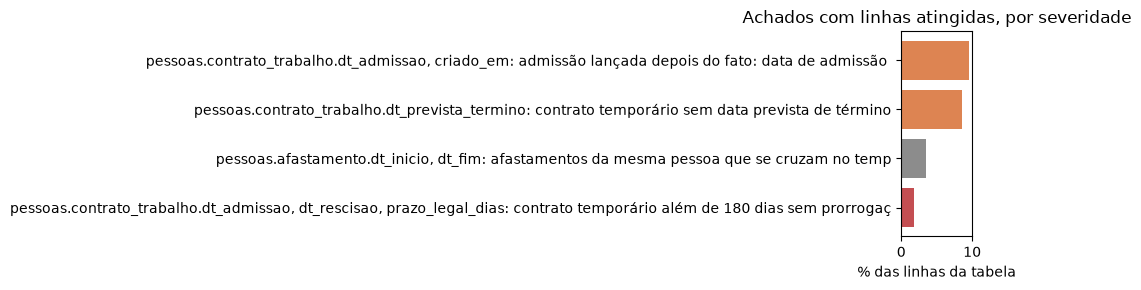

registro gravado em dados/auditoria/pessoas.json


In [21]:
com_linhas = quadro[quadro["linhas"] > 0].sort_values("pct")
if len(com_linhas):
    fig, eixo = plt.subplots(figsize=(10, max(3, 0.4 * len(com_linhas))))
    cores = {"alta": "#C44E52", "media": "#DD8452", "baixa": "#8C8C8C", "nenhuma": "#4C72B0"}
    eixo.barh(com_linhas["tabela"] + "." + com_linhas["coluna"] + ": " + com_linhas["achado"].str.slice(0, 50), com_linhas["pct"], color=[cores[s] for s in com_linhas["severidade"]])
    eixo.set_xlabel("% das linhas da tabela")
    eixo.set_title("Achados com linhas atingidas, por severidade")
    plt.tight_layout()
    plt.show()
caminho = registro.salvar(REFERENCIA.isoformat())
print(f"registro gravado em {caminho.relative_to(RAIZ)}")
con.close()

## Nota Técnica de fechamento

**O que foi examinado:** as 8 tabelas do domínio `pessoas`, 78 colunas e 108.852 linhas vivas, na carga identificada na seção 2: tipo, completude com coerência de status, unicidade e sobreposição, domínios, documentos, cronologia do vínculo, integridade referencial e as regras do negócio, com as duas declarações do cliente testadas.

**O veredicto: o cadastro de pessoa é limpo e o processo é que falha.** As duas declarações se confirmam com número: 1.621 admissões retroativas (9,5%, subindo ano a ano) e 263 temporários além de 180 dias sem prorrogação (32 ainda ativos; 85 além de 270 dias). Junto com eles, 1.281 temporários sem data prevista de término, que é o buraco por onde o prazo escapa. O cadastro em si passou em tudo: CPF válido e igual ao do candidato, nenhuma duplicidade, nenhuma alocação dupla, alocação sempre dentro do contrato e do posto, salário nunca abaixo do piso. Ficam para o catálogo um achado alto (prazo do temporário), dois médios (admissão retroativa, temporário sem previsão), um baixo (afastamentos sobrepostos) e três registros de severidade nenhuma (homologação pendente, documento válido, alocação íntegra).

**Próximos passos:** `ponto`, onde estas pessoas batem o relógio todo dia, e onde a batida que falta e a que se repete moram.